# Analyse Train results

L'objectif de ce notebook est d'analyser les résultats d'entraînements obtenus avec le script 2-autoencoder-convolution.
Ces résultats sont sauvegardés dans le fichier 0_train_results.csv.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("output/2-autoencoder-convolution/0_train_results.csv", sep=",")
df.head()

,date,category,resized_dimension,batch_size,grayscale,color_augmentation,move_augmentation,model_type,retrain_layers,loss,error_score,roc_auc,tpr,fpr
0,2026-07-10 19:20:20,bottle,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.939748,0.942446,0.500000
1,2026-07-10 19:21:57,transistor,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.766667,0.625000,0.200000
2,2026-07-10 19:26:08,cable,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.813156,0.619565,0.224138
3,2026-07-10 19:27:27,capsule,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.602314,0.293578,0.260870
4,2026-07-10 19:28:41,carpet,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.362360,0.258427,0.392857


In [ ]:
# Clean data

df["batch_size"] = df["batch_size"].astype(int)
df["resized_dimension"] = df["resized_dimension"].str.extract(r'(\d+)').astype(int)

df = df.replace({True:1, False:0})

# Sort values
df = df.sort_values(["category", "roc_auc"], ascending=[True, False])
df.head()

In [4]:
bests = df.loc[df.groupby(["category"])["roc_auc"].idxmax()]

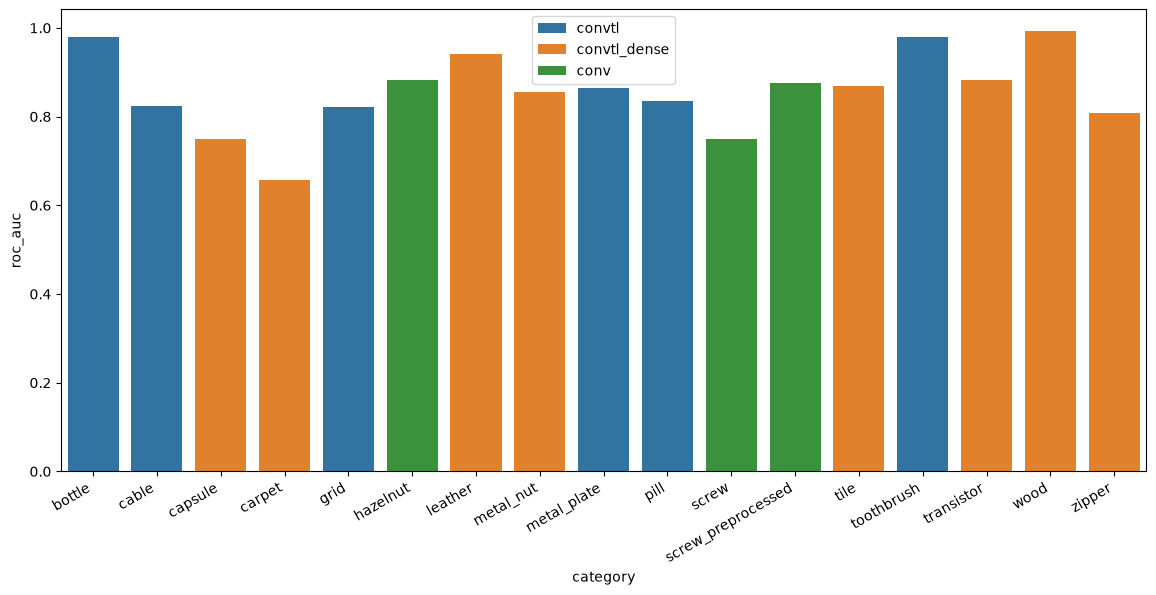

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.barplot(data=bests, x="category", y="roc_auc", hue="model_type")
plt.xticks(rotation=30, ha="right")

plt.legend()
plt.show();

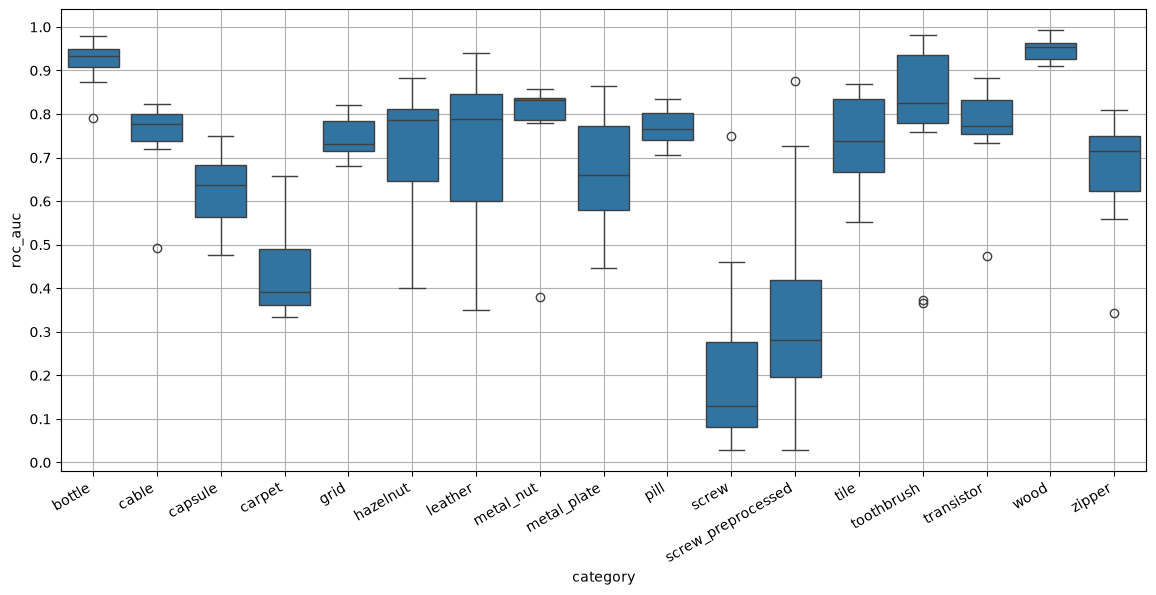

In [6]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="category", y="roc_auc")
plt.xticks(rotation=30, ha="right")

plt.yticks(np.arange(0,1.01,0.1), [f"{y:0.1f}" for y in np.arange(0,1.01,0.1)])
plt.grid(True)
plt.show();

In [7]:
df[df["category"]=="carpet"]

,date,category,resized_dimension,batch_size,grayscale,color_augmentation,move_augmentation,model_type,retrain_layers,loss,error_score,roc_auc,tpr,fpr
220,2026-07-22 21:07:33,carpet,256,8,1,0,0,convtl_dense,4,mae,mse,0.657303,0.662921,0.535714
109,2026-07-12 18:09:48,carpet,128,8,0,0,0,convtl_dense,4,mse,mae,0.650883,0.606742,0.285714
78,2026-07-12 15:21:19,carpet,128,8,0,0,0,convtl_dense,0,mse,mae,0.494783,0.337079,0.250000
203,2026-07-22 15:31:19,carpet,256,8,1,0,0,convtl,4,mae,mse,0.490770,0.629213,0.678571
125,2026-07-12 19:19:58,carpet,128,8,0,1,1,convtl_dense,-1,mse,mae,0.466292,0.235955,0.214286
93,2026-07-12 16:51:58,carpet,128,8,0,0,0,convtl_dense,0,mae,mse,0.455457,0.393258,0.392857
60,2026-07-11 18:34:41,carpet,128,16,0,0,0,convtl,0,mse,mae,0.392055,0.213483,0.250000
187,2026-07-22 12:35:11,carpet,256,8,1,0,0,conv,8,mae,mse,0.391252,0.617978,0.607143
131,2026-07-12 19:43:30,carpet,128,8,0,1,1,convtl,-1,mse,mae,0.376003,0.258427,0.285714
4,2026-07-10 19:28:41,carpet,128,16,0,1,1,convtl,0,mae,mse,0.362360,0.258427,0.392857
